**Part 1: Comparing Backends**

**Problem 1**

In [1]:
import torch
import torch._dynamo as dynamo

print(torch.__version__)
print("Available backends:", dynamo.list_backends())

2.10.0+cu128
Available backends: ['cudagraphs', 'inductor', 'openxla', 'tvm']


Device: cuda
eager: 0.003861 s/iter


W0317 03:56:41.534000 2200 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


inductor: 0.004089 s/iter
cudagraphs: 0.003538 s/iter


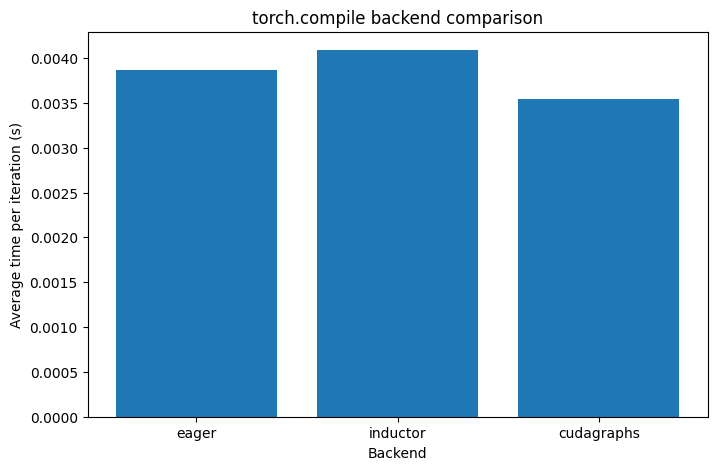

In [5]:
import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

class SimpleNet(nn.Module):
    def __init__(self, in_dim=1024, hidden=2048, out_dim=1024):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        return self.net(x)
def benchmark_backend(backend, steps=100, batch_size=256, in_dim=1024):
    model = SimpleNet(in_dim=in_dim).to(device)
    x = torch.randn(batch_size, in_dim, device=device)
    target = torch.randn(batch_size, in_dim, device=device)
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

    if backend == "eager":
        compiled_model = model
    else:
        compiled_model = torch.compile(model, backend=backend)

    # warmup
    for _ in range(5):
        optimizer.zero_grad(set_to_none=True)
        y = compiled_model(x)
        loss = ((y - target) ** 2).mean()
        loss.backward()
        optimizer.step()

    if device == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()

    for _ in range(steps):
        optimizer.zero_grad(set_to_none=True)
        y = compiled_model(x)
        loss = ((y - target) ** 2).mean()
        loss.backward()
        optimizer.step()

    if device == "cuda":
        torch.cuda.synchronize()

    end = time.perf_counter()
    return (end - start) / steps

candidate_backends = ["eager", "aot_eager", "inductor", "cudagraphs"]
available = set(torch._dynamo.list_backends())
backends = [b for b in candidate_backends if b == "eager" or b in available]

results = {}
for b in backends:
    try:
        avg_time = benchmark_backend(b, steps=100)
        results[b] = avg_time
        print(f"{b}: {avg_time:.6f} s/iter")
    except Exception as e:
        print(f"{b} failed: {e}")

plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values())
plt.ylabel("Average time per iteration (s)")
plt.xlabel("Backend")
plt.title("torch.compile backend comparison")
plt.show()

Why do different backends have different performance? What
are the tradeoff? Different backends have different performance because they apply different levels of graph capture and optimization. eager doesn't have compilation. inductor performs best because it lowers captured graphs to optimized kernels.

**Part 2: Debugging Compilation Failu**

In [7]:
def problem1(x):
    if x.sum() > 0:
        return x * 2
    else:
        return x / 2

In [8]:
import torch
import torch._dynamo as dynamo

x = torch.randn(4, 4)

try:
    compiled_p1 = torch.compile(problem1)
    print(compiled_p1(x))
except Exception as e:
    print("problem1 compile failed:", e)

print(dynamo.explain(problem1)(x))

tensor([[-0.9378, -3.2400,  1.3789,  2.7565],
        [-1.0627, -1.2869, -1.2590,  0.3339],
        [-1.1189,  1.7390,  1.6686,  1.4361],
        [-0.9696, -0.2404,  3.0987, -0.8883]])
Graph Count: 2
Graph Break Count: 1
Op Count: 2
Break Reasons:
  Break Reason 1:
    Reason: generic_jump TensorVariable()
    User Stack:
      <FrameSummary file /tmp/ipykernel_2200/3641715166.py, line 2 in problem1>
Ops per Graph:
  Ops 1:
    <built-in function gt>
  Ops 2:
    <built-in function mul>
Out Guards:
  Guard 1:
    Name: ''
    Source: shape_env
    Create Function: SHAPE_ENV
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 2:
    Name: ''
    Source: global
    Create Function: DETERMINISTIC_ALGORITHMS
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 3:
    Name: ''
    Source: global
    Create Function: GRAD_MODE
    Guard Types: None
    Code List: None
    Object Weakr

**Fixed version**

In [10]:
def problem1_fixed(x):
    cond = (x.sum() > 0)
    return torch.where(cond, x * 2, x / 2)

**Problem 2**

In [11]:
def problem2(x):
    d = {}
    d['key'] = x
    return d['key'] * 2

In [12]:
x = torch.randn(4, 4)

try:
    compiled_p2 = torch.compile(problem2)
    print(compiled_p2(x))
except Exception as e:
    print("problem2 compile failed:", e)

print(dynamo.explain(problem2)(x))

tensor([[ 0.4073,  1.0599,  3.6556, -1.3271],
        [-0.0221,  1.9278,  1.3080, -2.3426],
        [ 0.4093, -0.9255,  0.8514, -0.5334],
        [ 2.6062, -1.0711,  0.6468,  0.4723]])
Graph Count: 1
Graph Break Count: 0
Op Count: 1
Break Reasons:
Ops per Graph:
  Ops 1:
    <built-in function mul>
Out Guards:
  Guard 1:
    Name: ''
    Source: shape_env
    Create Function: SHAPE_ENV
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 2:
    Name: ''
    Source: global
    Create Function: DETERMINISTIC_ALGORITHMS
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 3:
    Name: ''
    Source: global
    Create Function: GRAD_MODE
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 4:
    Name: ''
    Source: global
    Create Function: DEFAULT_DEVICE
    Guard Types: ['DEFAULT_DEVICE']
    Code List: ['utils_device.CURREN

In [13]:
def problem2_fixed(x):
    return x * 2

**Problem 3**

In [14]:
def problem3(x):
    result = 0
    for i in range(10):
        result += (x ** i).sum()
    return result

In [15]:
x = torch.randn(512, 512)

compiled_p3 = torch.compile(problem3)
print(compiled_p3(x))

print(dynamo.explain(problem3)(x))

tensor(30870942.)
Graph Count: 1
Graph Break Count: 0
Op Count: 20
Break Reasons:
Ops per Graph:
  Ops 1:
    <built-in function pow>
    <built-in function add>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
Out Guards:
  Guard 1:
    Name: ''
    Source: shape_env
    Create Function: SHAPE_ENV
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 2:
    Name: ''
    Source: global
    Create Function: DETERMINISTIC_ALGORITHMS
    Guard Types: None
    Code List: None
    Ob

In [16]:
def problem3_fixed(x):
    powers = torch.arange(10, device=x.device, dtype=x.dtype).view(10, 1, 1)
    x_expanded = x.unsqueeze(0)
    return (x_expanded ** powers).sum()

**Part 3: Graph Capture and Inspection**

In [17]:
import torch
import torch.nn.functional as F
import torch._dynamo as dynamo
from torch.fx import symbolic_trace

def graph_fn(x, w1, w2, lst):
    y = x @ w1
    y = torch.relu(y)
    y = y @ w2
    y = y + x          # residual connection
    y = F.layer_norm(y, y.shape[-1:])

    print("Hello")
    lst.append(1)

    return y

x = torch.randn(8, 16)
w1 = torch.randn(16, 16)
w2 = torch.randn(16, 16)
lst = []

In [20]:
try:
    compiled_graph_fn = torch.compile(graph_fn, fullgraph=True)
    out = compiled_graph_fn(x, w1, w2, lst)
    print(out.shape)
except Exception as e:
    print("fullgraph compile failed:", e)
print(dynamo.explain(graph_fn)(x, w1, w2, []))

fullgraph compile failed: Failed to trace builtin operator
  Explanation: Dynamo does not know how to trace builtin operator `print` with argument types ['str'] (has_kwargs False)
  Hint: Avoid calling builtin `print` with argument types ['str']. Consider using an equivalent alternative function/method to `print`.
  Hint: If you are attempting to call a logging function (e.g. `print`), you can try adding it to `torch._dynamo.config.reorderable_logging_functions`.
  Hint: Please report an issue to PyTorch.

  Developer debug context: builtin print [<class 'torch._dynamo.variables.constant.ConstantVariable'>] False

 For more details about this graph break, please visit: https://meta-pytorch.github.io/compile-graph-break-site/gb/gb0059.html

from user code:
   File "/tmp/ipykernel_2200/2043159183.py", line 13, in graph_fn
    print("Hello")

Set TORCHDYNAMO_VERBOSE=1 for the internal stack trace (please do this especially if you're reporting a bug to PyTorch). For even more developer con

Which operations appear in the graph? It is matrix multiolication; ReLU; residual add and layer normalization.
Which operations are not captured? Why? print("Hello"). Becasue it is python side effects. What happens to the print statement? torch.compile could graph break, especially fullgraph=True. What happens to the list modification? It couldn't captured by tensor graph.

In [21]:
from torch. fx import symbolic_trace

def graph_fn_pure(x, w1, w2):
    y1 = x @ w1
    y2 = torch.relu(y1)
    y3 = y2 @ w2
    y4 = y3 + x          # residual connection
    y5 = F.layer_norm(y4, y4.shape[-1:])
    return y5
traced = symbolic_trace(graph_fn_pure)
print(traced)
print(traced.graph)

graph_fn_pure()



def forward(self, x, w1, w2):
    matmul = x @ w1;  w1 = None
    relu = torch.relu(matmul);  matmul = None
    matmul_1 = relu @ w2;  relu = w2 = None
    add = matmul_1 + x;  matmul_1 = x = None
    getattr_1 = add.shape
    getitem = getattr_1[slice(-1, None, None)];  getattr_1 = None
    layer_norm = torch.nn.functional.layer_norm(add, getitem, weight = None, bias = None, eps = 1e-05);  add = getitem = None
    return layer_norm
    
# To see more debug info, please use `graph_module.print_readable()`
graph():
    %x : [num_users=2] = placeholder[target=x]
    %w1 : [num_users=1] = placeholder[target=w1]
    %w2 : [num_users=1] = placeholder[target=w2]
    %matmul : [num_users=1] = call_function[target=operator.matmul](args = (%x, %w1), kwargs = {})
    %relu : [num_users=1] = call_function[target=torch.relu](args = (%matmul,), kwargs = {})
    %matmul_1 : [num_users=1] = call_function[target=operator.matmul](args = (%relu, %w2), kwargs = {})
    %add : [num_user